In [22]:
#2.5 seconds mai split


import numpy as np
from scipy.io import loadmat, savemat

# Load original EEG data
data = loadmat('/Users/aryanjaswal/Projects/IMAGINE MAT/DATASET (NEW)/up.mat')
mat_key = 'eeg_data_wrt_task_rep_no_eog_256Hz_last_beep'
eeg_data = data[mat_key]
print("Original EEG shape:", eeg_data.shape)

# Create empty containers for each half
shape = eeg_data.shape  # (8, 100)
first_half = np.empty(shape, dtype=object)
second_half = np.empty(shape, dtype=object)

# Split each cell (64, 1280) → (64, 640) and store
for i in range(shape[0]):
    for j in range(shape[1]):
        signal = eeg_data[i, j]
        if isinstance(signal, np.ndarray) and signal.shape[1] == 1280:
            first_half[i, j] = signal[:, :640]   # 0–2.5 seconds
            second_half[i, j] = signal[:, 640:]  # 2.5–5.0 seconds
        else:
            print(f"⚠️ Unexpected shape at ({i}, {j}):", signal.shape)

# Save the two new containers to separate .mat files
savemat('up1.mat', {mat_key: first_half})
savemat('up2.mat', {mat_key: second_half})

print("✅ EEG data split and saved as 2.5s segments.")

Original EEG shape: (6, 100)
✅ EEG data split and saved as 2.5s segments.


In [ ]:
# size and shape check

import numpy as np
from scipy.io import loadmat

# Load the .mat file
data = loadmat('/Users/aryanjaswal/Projects/IMAGINE MAT/DECOMPOSE DATASET/a|.mat')

# Access the EEG data variable
eeg_data = data['eeg_data_wrt_task_rep_no_eog_256Hz_last_beep']

# Print the shape of the container (e.g., trials × repetitions)
print("EEG data container shape:", eeg_data.shape)

# Inspect the type and content of one cell (e.g., first trial)
cell = eeg_data[0, 0]

print("Type of first cell:", type(cell))
print("Shape of data inside first cell:", cell.shape)

# Determine number of channels
if isinstance(cell, np.ndarray):
    if cell.ndim == 1:
        num_channels = cell.shape[0]
    elif cell.ndim >= 2:
        num_channels = cell.shape[0]  # channels are usually along axis 0
    else:
        num_channels = "Unknown"
else:
    num_channels = "Not a NumPy array"

print("✅ Number of EEG channels:", num_channels)

EEG data container shape: (8, 200)
Type of first cell: <class 'numpy.ndarray'>
Shape of data inside first cell: (64, 640)
✅ Number of EEG channels: 64


In [ ]:
# a1+a2

import numpy as np
from scipy.io import loadmat, savemat

# Key used in both .mat files
mat_key = 'eeg_data_wrt_task_rep_no_eog_256Hz_last_beep'

# Load both files
first_data = loadmat('/Users/aryanjaswal/Projects/IMAGINE MAT/DECOMPOSE DATASET/up1.mat')[mat_key]
last_data = loadmat('/Users/aryanjaswal/Projects/IMAGINE MAT/DECOMPOSE DATASET/up2.mat')[mat_key]

print("First half shape:", first_data.shape)
print("Last half shape:", last_data.shape)

# Combine horizontally (axis=1 → columns/trials)
combined_data = np.concatenate((first_data, last_data), axis=1)

print("✅ Combined shape:", combined_data.shape)  # Should be (8, 200)

# Save to new .mat file
savemat('/Users/aryanjaswal/Projects/IMAGINE MAT/DECOMPOSE DATASET/up|.mat', {mat_key: combined_data})

print("✅ Combined .mat file saved.")

First half shape: (6, 100)
Last half shape: (6, 100)
✅ Combined shape: (6, 200)
✅ Combined .mat file saved.


In [25]:
import numpy as np
from scipy.io import loadmat
from scipy.stats import kurtosis, skew
from scipy.signal import welch
from scipy.integrate import simps
import pandas as pd

# -------------------------------
# Step 1: Load EEG data
# -------------------------------
mat_file_path = '/Users/aryanjaswal/Projects/IMAGINE MAT/DECOMPOSE DATASET/a|.mat'
mat_key = 'eeg_data_wrt_task_rep_no_eog_256Hz_last_beep'
data = loadmat(mat_file_path)
eeg_data = data[mat_key]  # shape: (8, 200)
print("Loaded EEG data shape:", eeg_data.shape)

# -------------------------------
# Step 2: Feature extraction setup
# -------------------------------
fs = 256  # Sampling frequency (Hz)
freq_bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 45)
}

def extract_features(trial):  # trial shape: (64, 640)
    features = []
    for channel in trial:
        # Time-domain features
        features.append(np.mean(channel))
        features.append(np.std(channel))
        features.append(skew(channel))
        features.append(kurtosis(channel))
        features.append(np.sqrt(np.mean(channel**2)))  # RMS
        features.append(np.ptp(channel))  # Peak-to-peak

        # Frequency-domain features
        freqs, psd = welch(channel, fs=fs)
        for band_range in freq_bands.values():
            low, high = band_range
            idx = np.logical_and(freqs >= low, freqs <= high)
            band_power = simps(psd[idx], freqs[idx])
            features.append(band_power)
    return features  # 64 × (6 + 5) = 704 features

# -------------------------------
# Step 3: Loop through all trials and extract features
# -------------------------------
all_features = []

for i in range(eeg_data.shape[0]):      # 8 tasks
    for j in range(eeg_data.shape[1]):  # 200 trials
        trial = eeg_data[i, j]          # shape: (64, 640)
        features = extract_features(trial)
        all_features.append(features)

X = np.array(all_features)  # Final feature matrix: (1600, 704)
print("✅ Feature matrix shape:", X.shape)

# -------------------------------
# Step 4: Save features
# -------------------------------
# Save as CSV
csv_path = 'a_features.csv'
pd.DataFrame(X).to_csv(csv_path, index=False)
print(f"✅ Features saved to CSV: {csv_path}")

# Save as .npy
npy_path = 'a_features.npy'
np.save(npy_path, X)
print(f"✅ Features saved to NPY: {npy_path}")

Loaded EEG data shape: (8, 200)


/var/folders/jg/v0bbfb4d6z31kv3sqwt32tr40000gn/T/ipykernel_4878/2551380450.py:45: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  band_power = simps(psd[idx], freqs[idx])


✅ Feature matrix shape: (1600, 704)
✅ Features saved to CSV: a_features.csv
✅ Features saved to NPY: a_features.npy


In [35]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import welch
from scipy.integrate import simps
from scipy.stats import kurtosis, skew
import pywt

# Set sampling frequency
fs = 256

# --- Feature Functions ---

def spectral_entropy(psd):
    psd_norm = psd / np.sum(psd)
    return -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

def hjorth_params(signal):
    d1 = np.diff(signal)
    d2 = np.diff(d1)
    activity = np.var(signal)
    mobility = np.std(d1) / (np.std(signal) + 1e-12)
    complexity = (np.std(d2) / (np.std(d1) + 1e-12)) / (mobility + 1e-12)
    return activity, mobility, complexity

def wavelet_entropy(signal, wavelet='db4', level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    energies = np.array([np.sum(c**2) for c in coeffs])
    probs = energies / (np.sum(energies) + 1e-12)
    entropy = -np.sum(probs * np.log2(probs + 1e-12))
    return entropy, np.sum(energies)

def frequency_statistics(freqs, psd):
    psd_norm = psd / np.sum(psd)
    mean_freq = np.sum(freqs * psd_norm)
    median_freq = freqs[np.searchsorted(np.cumsum(psd_norm), 0.5)]
    peak_freq = freqs[np.argmax(psd)]
    freq_var = np.sum((freqs - mean_freq) ** 2 * psd_norm)
    return mean_freq, median_freq, freq_var, peak_freq

# --- Feature Extractor for One Trial (averaged over 64 channels) ---

def extract_mean_features(trial):  # trial shape: (64, 640)
    feature_matrix = []
    for ch in trial:
        freqs, psd = welch(ch, fs=fs)

        # Time-domain features
        mean = np.mean(ch)
        std = np.std(ch)
        sk = skew(ch)
        kurt = kurtosis(ch)
        rms = np.sqrt(np.mean(ch**2))
        ptp = np.ptp(ch)

        # Hjorth features
        act, mob, comp = hjorth_params(ch)

        # Spectral features
        spec_ent = spectral_entropy(psd)
        total_power = simps(psd, freqs)
        mean_f, med_f, var_f, peak_f = frequency_statistics(freqs, psd)

        # Wavelet features
        wave_ent, coeff_energy = wavelet_entropy(ch)

        # Combine features
        features = [
            mean, std, sk, kurt, rms, ptp,
            act, mob, comp,
            spec_ent, total_power, wave_ent, coeff_energy,
            med_f, mean_f, var_f, peak_f
        ]
        feature_matrix.append(features)

    return np.mean(np.array(feature_matrix), axis=0)  # shape: (18,)

# --- Load EEG Data and Process All Trials ---

mat_path = "/Users/aryanjaswal/Projects/IMAGINE MAT/DECOMPOSE DATASET/up|.mat"
mat_key = "eeg_data_wrt_task_rep_no_eog_256Hz_last_beep"

data = loadmat(mat_path)
eeg_data = data[mat_key]  # shape: (8, 200)

all_mean_features = []

for i in range(eeg_data.shape[0]):
    for j in range(eeg_data.shape[1]):
        trial = eeg_data[i, j]  # shape: (64, 640)
        trial_feats = extract_mean_features(trial)
        all_mean_features.append(trial_feats)

X = np.array(all_mean_features)  # shape: (1600, 18)
print("✅ Final mean feature matrix shape:", X.shape)

# --- Save to CSV with Feature Labels ---

feature_names = [
    'mean', 'std', 'skewness', 'kurtosis', 'rms', 'peak_to_peak',
    'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity',
    'spectral_entropy', 'total_power', 'wavelet_entropy', 'coeff_energy',
    'median_frequency', 'mean_frequency', 'frequency_variance', 'peak_frequency'
]

csv_path = "up_features.csv"
df = pd.DataFrame(X, columns=feature_names)
df.to_csv(csv_path, index=False)

print(f"✅ Mean features saved to: {csv_path}")

/var/folders/jg/v0bbfb4d6z31kv3sqwt32tr40000gn/T/ipykernel_4878/2035688532.py:61: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  total_power = simps(psd, freqs)


✅ Final mean feature matrix shape: (1200, 17)
✅ Mean features saved to: up_features.csv


In [44]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/independent_features.csv", header=None)

# Add '0' as the last column
df['label'] = 8

# Save the updated CSV
df.to_csv("/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/independent_features.csv", index=False, header=False)

In [8]:
import pandas as pd

# List your CSV files here
file_list = ["/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/a_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/i_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/u_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/out_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/in_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/up_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/cooperate_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/independent_features.csv"
            ]  # Replace with actual file names

all_labels = []

for file in file_list:
    df = pd.read_csv(file, header=None, skiprows=1)  # Skip header row
    last_col = df.iloc[:, -1]
    all_labels.extend(last_col.tolist())

# Convert to DataFrame and add "label" as first cell
label_df = pd.DataFrame(all_labels, columns=["label"])

# Save to CSV with header
label_df.to_csv("labels.csv", index=False)

In [9]:
import pandas as pd

# List your CSV files directly
csv_files = ["/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/a_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/i_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/u_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/out_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/in_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/up_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/cooperate_features.csv",
            "/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/independent_features.csv"
            ]   # Replace with your actual file names

# List to store processed DataFrames
df_list = []

# Loop through each file
for file in csv_files:
    df = pd.read_csv(file)
    df = df.iloc[:, :-1]  # Drop the last column
    df_list.append(df)

# Combine all dataframes vertically
combined_df = pd.concat(df_list, ignore_index=True)

# Save to a new CSV file
combined_df.to_csv('combined.csv', index=False)

print("Combined CSV saved as 'combined_output.csv'")

Combined CSV saved as 'combined_output.csv'


In [14]:



import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# Load CSV files and skip header
X = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/combined.csv', header=None, skiprows=1)
y = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/labels.csv', header=None, skiprows=1).squeeze()

# 10-fold stratified cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold = 1
for train_idx, test_idx in kf.split(X, y):
    print(f"\nFold {fold}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Train Random Forest for feature importance
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)

    # Select top 10 features based on importance
    top_features = rf.feature_importances_.argsort()[::-1][:10]
    X_train_selected = X_train.iloc[:, top_features]
    X_test_selected = X_test.iloc[:, top_features]

    # Retrain model on selected features
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_selected, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test_selected)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy with top 10 features: {acc:.4f}")

    fold += 1


Fold 1
Accuracy with top 10 features: 0.2481

Fold 2
Accuracy with top 10 features: 0.2954

Fold 3
Accuracy with top 10 features: 0.2398

Fold 4
Accuracy with top 10 features: 0.2343

Fold 5
Accuracy with top 10 features: 0.2565

Fold 6
Accuracy with top 10 features: 0.2528

Fold 7
Accuracy with top 10 features: 0.2574

Fold 8
Accuracy with top 10 features: 0.2815

Fold 9
Accuracy with top 10 features: 0.2343

Fold 10
Accuracy with top 10 features: 0.2287


In [15]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load data without headers (skip first row)
X = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/combined.csv', header=None, skiprows=1)
y = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/labels.csv', header=None, skiprows=1).squeeze()

# Initialize 10-fold cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Initialize models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', probability=True),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

# Track fold results
for model_name, model in models.items():
    print(f"\n===== {model_name} =====")
    fold = 1
    accuracies = []

    for train_idx, test_idx in kf.split(X, y):
        # Split data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Train and evaluate
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        print(f"Fold {fold}: Accuracy = {acc:.4f}")
        fold += 1

    print(f"Average Accuracy = {sum(accuracies)/len(accuracies):.4f}")


===== Random Forest =====
Fold 1: Accuracy = 0.2454
Fold 2: Accuracy = 0.2417
Fold 3: Accuracy = 0.2491
Fold 4: Accuracy = 0.2380
Fold 5: Accuracy = 0.2583
Fold 6: Accuracy = 0.2685
Fold 7: Accuracy = 0.2491
Fold 8: Accuracy = 0.2787
Fold 9: Accuracy = 0.2574
Fold 10: Accuracy = 0.2472
Average Accuracy = 0.2533

===== SVM =====
Fold 1: Accuracy = 0.1481
Fold 2: Accuracy = 0.1481
Fold 3: Accuracy = 0.1481
Fold 4: Accuracy = 0.1481
Fold 5: Accuracy = 0.1481
Fold 6: Accuracy = 0.1472
Fold 7: Accuracy = 0.1481
Fold 8: Accuracy = 0.1481
Fold 9: Accuracy = 0.1481
Fold 10: Accuracy = 0.1481
Average Accuracy = 0.1481

===== Logistic Regression =====


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1: Accuracy = 0.1657


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2: Accuracy = 0.1491


...

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 8: Accuracy = 0.1463


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 9: Accuracy = 0.1444
Fold 10: Accuracy = 0.1417
Average Accuracy = 0.1489


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== Random Forest =====
Fold 1: Accuracy = 0.2491
Fold 2: Accuracy = 0.2565
Fold 3: Accuracy = 0.2491
Fold 4: Accuracy = 0.2398
Fold 5: Accuracy = 0.2472
Fold 6: Accuracy = 0.2676
Fold 7: Accuracy = 0.2519
Fold 8: Accuracy = 0.2583
Fold 9: Accuracy = 0.2500
Fold 10: Accuracy = 0.2361
Average Accuracy = 0.2506

===== SVM (RBF) =====
Fold 1: Accuracy = 0.1481
Fold 2: Accuracy = 0.1481
Fold 3: Accuracy = 0.1481
Fold 4: Accuracy = 0.1481
Fold 5: Accuracy = 0.1481
Fold 6: Accuracy = 0.1481
Fold 7: Accuracy = 0.1481
Fold 8: Accuracy = 0.1481
Fold 9: Accuracy = 0.1481
Fold 10: Accuracy = 0.1481
Average Accuracy = 0.1481

===== Logistic Regression =====


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1: Accuracy = 0.1583


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2: Accuracy = 0.1509


...

Fold 8: Accuracy = 0.1398


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 9: Accuracy = 0.1407


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 10: Accuracy = 0.1435
Average Accuracy = 0.1509

===== KNN =====
Fold 1: Accuracy = 0.1583
Fold 2: Accuracy = 0.1509
Fold 3: Accuracy = 0.1491
Fold 4: Accuracy = 0.1537
Fold 5: Accuracy = 0.1630
Fold 6: Accuracy = 0.1435
Fold 7: Accuracy = 0.1491
Fold 8: Accuracy = 0.1444
Fold 9: Accuracy = 0.1417
Fold 10: Accuracy = 0.1370
Average Accuracy = 0.1491

===== Naive Bayes =====
Fold 1: Accuracy = 0.1148
Fold 2: Accuracy = 0.1130
Fold 3: Accuracy = 0.1167
Fold 4: Accuracy = 0.1102
Fold 5: Accuracy = 0.1157
Fold 6: Accuracy = 0.1315
Fold 7: Accuracy = 0.1194
Fold 8: Accuracy = 0.1185
Fold 9: Accuracy = 0.1231
Fold 10: Accuracy = 0.1120
Average Accuracy = 0.1175

===== Decision Tree =====
Fold 1: Accuracy = 0.2065
Fold 2: Accuracy = 0.1944
Fold 3: Accuracy = 0.2167
Fold 4: Accuracy = 0.2120
Fold 5: Accuracy = 0.2185
Fold 6: Accuracy = 0.1981
Fold 7: Accuracy = 0.2056
Fold 8: Accuracy = 0.2296
Fold 9: Accuracy = 0.1935
Fold 10: Accuracy = 0.1907
Average Accuracy = 0.2066

===== Gradient B

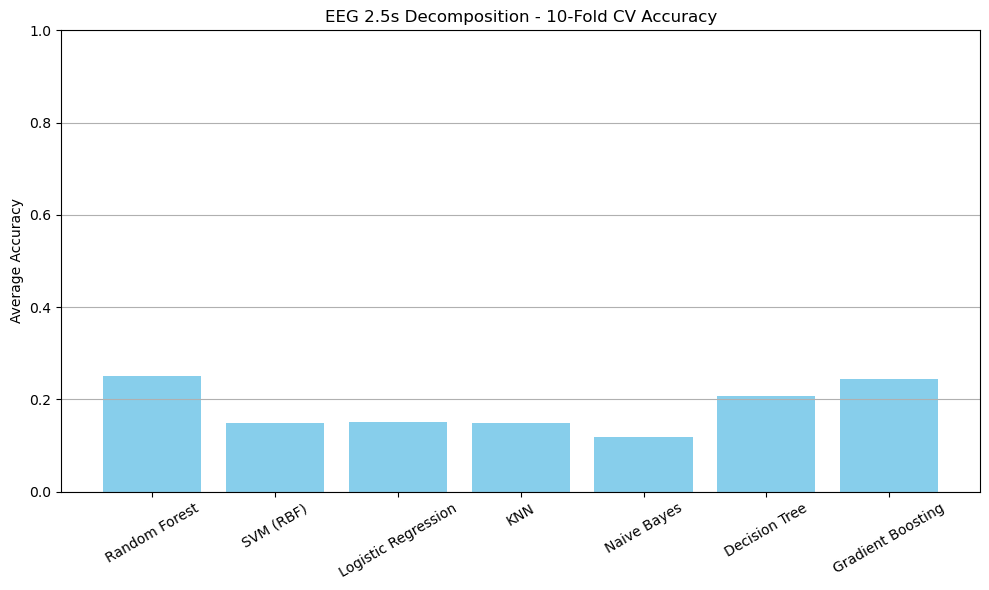

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Load data
X = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/combined.csv', header=None, skiprows=1)
y = pd.read_csv('/Users/aryanjaswal/Projects/IMAGINE MAT/2.5 features/labels.csv', header=None, skiprows=1).squeeze()

# 10-fold stratified cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define tuned models (basic tuning)
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', C=10, gamma='scale', probability=True),
    "Logistic Regression": LogisticRegression(max_iter=2000, C=1.0),
    "KNN": KNeighborsClassifier(n_neighbors=5, metric='minkowski'),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42),
}

# Evaluate models
model_accuracies = {}

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")
    fold = 1
    accuracies = []

    for train_idx, test_idx in kf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        print(f"Fold {fold}: Accuracy = {acc:.4f}")
        fold += 1

    avg_acc = sum(accuracies) / len(accuracies)
    model_accuracies[model_name] = avg_acc
    print(f"Average Accuracy = {avg_acc:.4f}")

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(model_accuracies.keys(), model_accuracies.values(), color='skyblue')
plt.ylabel('Average Accuracy')
plt.ylim(0, 1)
plt.title('EEG 2.5s Decomposition - 10-Fold CV Accuracy')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


===== Random Forest =====
Fold 1: Accuracy = 0.2359
Fold 2: Accuracy = 0.2363
Fold 3: Accuracy = 0.2330
Fold 4: Accuracy = 0.2344
Fold 5: Accuracy = 0.2356
Fold 6: Accuracy = 0.2259
Fold 7: Accuracy = 0.2219
Fold 8: Accuracy = 0.2259
Fold 9: Accuracy = 0.2304
Fold 10: Accuracy = 0.2274
Average Accuracy = 0.2307

===== Logistic Regression =====


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1: Accuracy = 0.1489


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2: Accuracy = 0.1456


...

Fold 8: Accuracy = 0.1585


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 9: Accuracy = 0.1474


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 10: Accuracy = 0.1522
Average Accuracy = 0.1510

===== KNN =====
Fold 1: Accuracy = 0.1544
Fold 2: Accuracy = 0.1467
Fold 3: Accuracy = 0.1500
Fold 4: Accuracy = 0.1474
Fold 5: Accuracy = 0.1626
Fold 6: Accuracy = 0.1489
Fold 7: Accuracy = 0.1633
Fold 8: Accuracy = 0.1422
Fold 9: Accuracy = 0.1530
Fold 10: Accuracy = 0.1478
Average Accuracy = 0.1516

===== Naive Bayes =====
Fold 1: Accuracy = 0.1181
Fold 2: Accuracy = 0.1152
Fold 3: Accuracy = 0.1181
Fold 4: Accuracy = 0.1144
Fold 5: Accuracy = 0.1156
Fold 6: Accuracy = 0.1137
Fold 7: Accuracy = 0.1141
Fold 8: Accuracy = 0.1144
Fold 9: Accuracy = 0.1278
Fold 10: Accuracy = 0.1156
Average Accuracy = 0.1167

===== Decision Tree =====
Fold 1: Accuracy = 0.1896
Fold 2: Accuracy = 0.1863
Fold 3: Accuracy = 0.1826
Fold 4: Accuracy = 0.1989
Fold 5: Accuracy = 0.1948
Fold 6: Accuracy = 0.2033
Fold 7: Accuracy = 0.1933
Fold 8: Accuracy = 0.1974
Fold 9: Accuracy = 0.1848
Fold 10: Accuracy = 0.1841
Average Accuracy = 0.1915


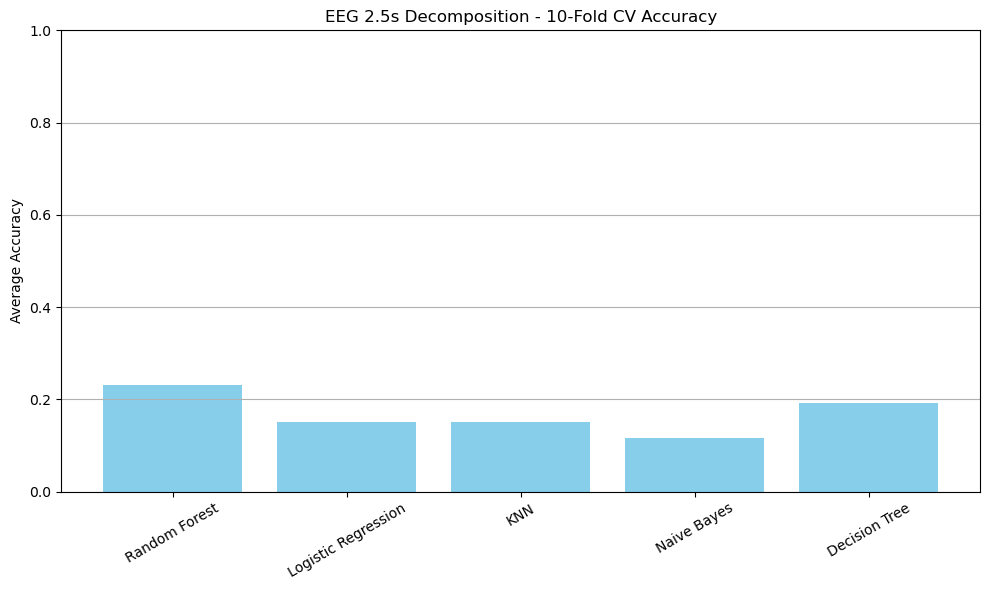